In [1]:
# =============================================================
# Accountability Graph Extraction
# Project 2 of 4 — Computational Accountability Framework
# =============================================================
# Research Question:
# Can we extract accountability relationships from regulatory
# text and represent them as a structured graph?
#
# Method: relation extraction + dependency parsing + graph modeling
# Data: FDA Warning Letter corpus (N=50, 2016-2025)
# =============================================================

import pandas as pd
import numpy as np
import json
from collections import defaultdict

print("Environment ready!")

Environment ready!


In [3]:
# -------------------------------------------------------------
# Step 1: Load FDA Warning Letter corpus
# -------------------------------------------------------------

fda_df = pd.read_excel(r'C:\Users\user\FDA_Warning Letter.xlsx')

print(f"Shape: {fda_df.shape}")
print(f"Columns: {fda_df.columns.tolist()}")
print(f"\nPreview:")
print(fda_df.head(10))

Shape: (160, 5)
Columns: ['CaseID', 'ViolationID', 'CFR', 'ResponsibilitySubject', 'ViolationText']

Preview:
      CaseID ViolationID                 CFR ResponsibilitySubject  \
0  WL2016-01          V1  211.42(c)(10)(iv))                  Firm   
1  WL2016-01          V2          211.113(b)                  Firm   
2  WL2016-02          V1       211.194(a)(4)                  Firm   
3  WL2016-02          V2             211.192                  Firm   
4  WL2016-03          V1             211.192                  Firm   
5  WL2016-03          V2          211.194(a)                  Firm   
6  WL2016-03          V3           211.22(d)                  Firm   
7  WL2016-03          V4          211.110(a)                  Firm   
8  WL2016-03          V5          211.110(c)    QualityControlUnit   
9  WL2016-03          V6           211.68(b)                  Firm   

                     ViolationText  
0  environmental monitoring system  
1               written procedures  
2    lab

In [4]:
# -------------------------------------------------------------
# Step 2: Define accountability relation types
# Extract triples: (subject, relation, object)
# -------------------------------------------------------------

triples = []

for _, row in fda_df.iterrows():
    case_id = row['CaseID']
    violation_id = row['ViolationID']
    cfr = row['CFR']
    subject = row['ResponsibilitySubject']
    text = row['ViolationText']
    
    # Triple 1: Firm VIOLATES CFR
    triples.append({
        'case_id': case_id,
        'source': subject,
        'relation': 'VIOLATES',
        'target': cfr,
        'violation_id': violation_id
    })
    
    # Triple 2: Violation INVOLVES text category
    triples.append({
        'case_id': case_id,
        'source': violation_id,
        'relation': 'INVOLVES',
        'target': text,
        'violation_id': violation_id
    })

triples_df = pd.DataFrame(triples)

print(f"Total triples extracted: {len(triples_df)}")
print(f"\nRelation distribution:")
print(triples_df['relation'].value_counts())
print(f"\nPreview:")
print(triples_df.head(6))

Total triples extracted: 320

Relation distribution:
relation
VIOLATES    160
INVOLVES    160
Name: count, dtype: int64

Preview:
     case_id source  relation                           target violation_id
0  WL2016-01   Firm  VIOLATES               211.42(c)(10)(iv))           V1
1  WL2016-01     V1  INVOLVES  environmental monitoring system           V1
2  WL2016-01   Firm  VIOLATES                       211.113(b)           V2
3  WL2016-01     V2  INVOLVES               written procedures           V2
4  WL2016-02   Firm  VIOLATES                    211.194(a)(4)           V1
5  WL2016-02     V1  INVOLVES    laboratory records incomplete           V1


In [5]:
# -------------------------------------------------------------
# Step 3: Build accountability graph with networkx
# -------------------------------------------------------------

try:
    import networkx as nx
    print("networkx ready!")
except:
    import subprocess
    subprocess.run(['pip', 'install', 'networkx', '--quiet'])
    import networkx as nx
    print("networkx installed and ready!")

# Build directed graph
G = nx.DiGraph()

for _, row in triples_df.iterrows():
    G.add_edge(
        row['source'],
        row['target'],
        relation=row['relation'],
        case_id=row['case_id']
    )

print(f"\nGraph stats:")
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"\nTop 10 nodes by degree:")
degree_sorted = sorted(G.degree(), key=lambda x: x[1], reverse=True)
for node, degree in degree_sorted[:10]:
    print(f"  {node}: {degree}")

networkx ready!

Graph stats:
Nodes: 205
Edges: 200

Top 10 nodes by degree:
  V1: 49
  V2: 48
  Firm: 42
  V3: 37
  V4: 16
  V5: 6
  inadequate environmental and personnel monitoring in aseptic processing areas: 2
  inadequate process validation and lack of ongoing process monitoring for OTC drug products: 2
  failure to perform identity testing of incoming components and qualify supplier COA reliability: 2
  211.42(c)(10)(iv)): 1


In [6]:
# -------------------------------------------------------------
# Step 4: Rebuild graph with unique violation nodes
# Use case_id + violation_id as unique node identifier
# -------------------------------------------------------------

G2 = nx.DiGraph()

for _, row in fda_df.iterrows():
    case_id = row['CaseID']
    violation_id = row['ViolationID']
    cfr = row['CFR']
    subject = row['ResponsibilitySubject']
    text = row['ViolationText']
    
    # Unique violation node
    violation_node = f"{case_id}_{violation_id}"
    
    # subject VIOLATES cfr
    G2.add_edge(subject, cfr, 
                relation='VIOLATES', 
                case_id=case_id)
    
    # subject ATTRIBUTED_TO violation
    G2.add_edge(violation_node, subject, 
                relation='ATTRIBUTED_TO',
                case_id=case_id)
    
    # violation INVOLVES text
    G2.add_edge(violation_node, text, 
                relation='INVOLVES',
                case_id=case_id)

print(f"Graph stats:")
print(f"Nodes: {G2.number_of_nodes()}")
print(f"Edges: {G2.number_of_edges()}")

print(f"\nTop 10 nodes by in-degree:")
in_degree = sorted(G2.in_degree(), key=lambda x: x[1], reverse=True)
for node, deg in in_degree[:10]:
    print(f"  {node}: {deg}")

Graph stats:
Nodes: 359
Edges: 363

Top 10 nodes by in-degree:
  Firm: 159
  failure to perform identity testing of incoming components and qualify supplier COA reliability: 3
  inadequate laboratory controls and method validation: 2
  inadequate environmental and personnel monitoring in aseptic processing areas: 2
  inadequate equipment cleaning and cross-contamination control: 2
  inadequate process validation and lack of ongoing process monitoring for OTC drug products: 2
  211.42(c)(10)(iv)): 1
  environmental monitoring system: 1
  211.113(b): 1
  written procedures: 1


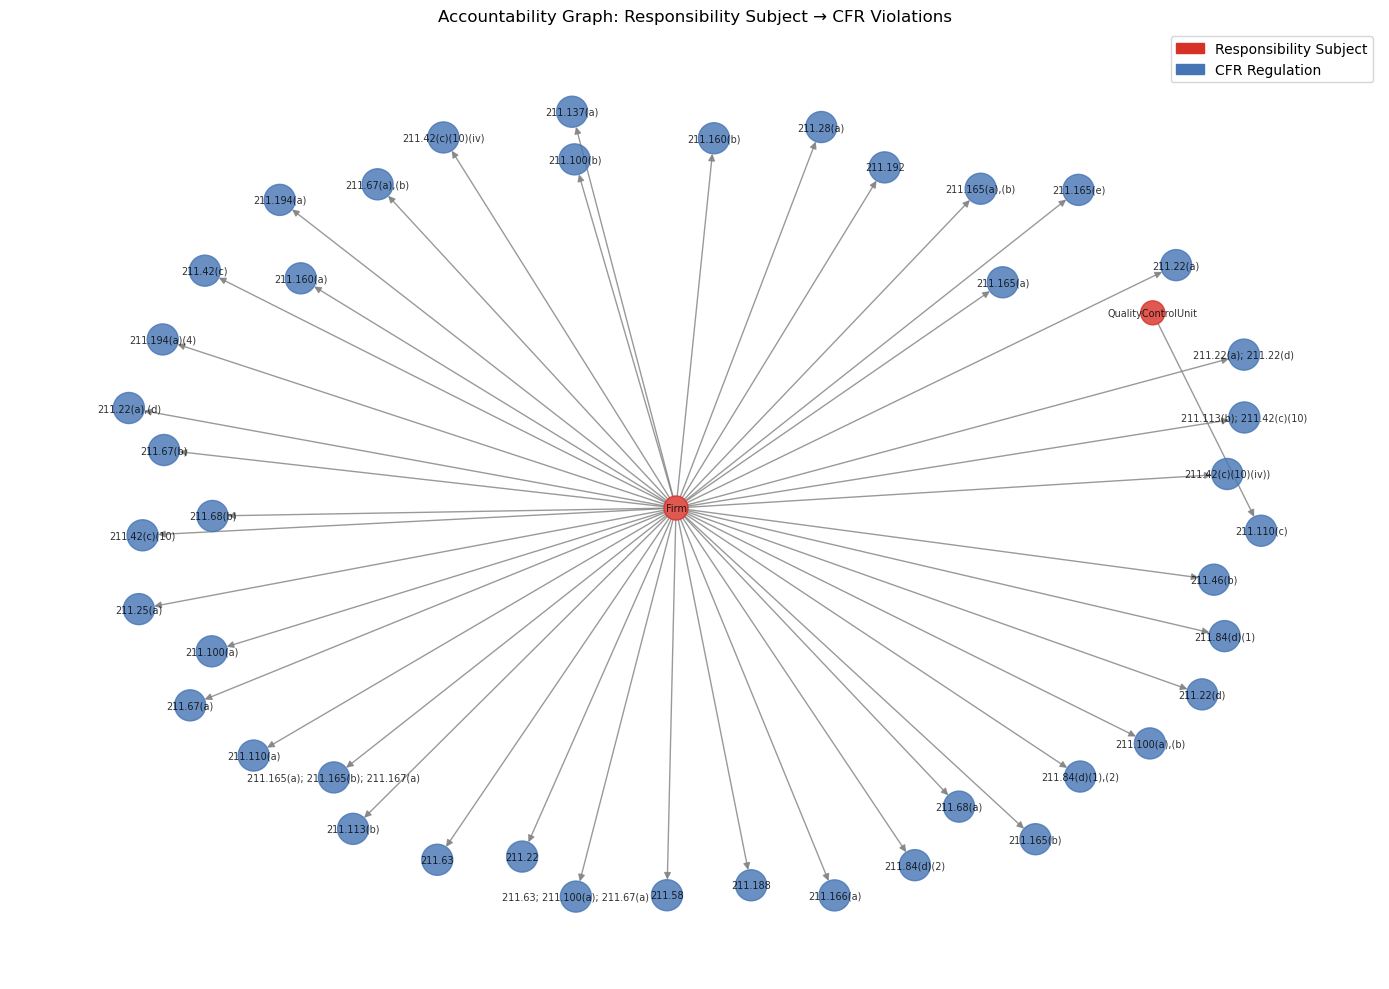

Saved!


In [8]:
# -------------------------------------------------------------
# Step 5: Visualize accountability graph
# -------------------------------------------------------------

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Focus on CFR nodes only (cleaner visualization)
subject_nodes = ['Firm', 'QualityControlUnit']

# Subgraph: subject → CFR edges only
edges_to_show = [(u, v) for u, v, d in G2.edges(data=True) 
                 if d['relation'] == 'VIOLATES']

SG = nx.DiGraph()
SG.add_edges_from(edges_to_show)

# Node colors
color_map = []
for node in SG.nodes():
    if node in subject_nodes:
        color_map.append('#d73027')
    else:
        color_map.append('#4575b4')

# Node sizes by degree
sizes = [300 + SG.in_degree(n) * 200 for n in SG.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(SG, seed=42, k=2)

nx.draw_networkx(
    SG, pos,
    node_color=color_map,
    node_size=sizes,
    font_size=7,
    arrows=True,
    arrowsize=10,
    edge_color='gray',
    alpha=0.8,
    ax=ax
)

red_patch = mpatches.Patch(color='#d73027', label='Responsibility Subject')
blue_patch = mpatches.Patch(color='#4575b4', label='CFR Regulation')
ax.legend(handles=[red_patch, blue_patch])
ax.set_title('Accountability Graph: Responsibility Subject → CFR Violations')
ax.axis('off')

plt.tight_layout()
plt.savefig('figures/graph_accountability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [9]:
# -------------------------------------------------------------
# Step 6: Graph centrality analysis
# Which nodes are most "accountable" in the network?
# -------------------------------------------------------------

# In-degree centrality — who receives the most accountability arrows
in_degree_centrality = nx.in_degree_centrality(G2)
out_degree_centrality = nx.out_degree_centrality(G2)
betweenness_centrality = nx.betweenness_centrality(G2)

# Convert to dataframes
centrality_df = pd.DataFrame({
    'node': list(in_degree_centrality.keys()),
    'in_degree': list(in_degree_centrality.values()),
    'out_degree': list(out_degree_centrality.values()),
    'betweenness': list(betweenness_centrality.values())
}).sort_values('in_degree', ascending=False)

print("Top 10 nodes by in-degree centrality:")
print(centrality_df.head(10).to_string(index=False))

print(f"\nTop 10 nodes by betweenness centrality:")
print(centrality_df.sort_values('betweenness', ascending=False).head(10).to_string(index=False))

Top 10 nodes by in-degree centrality:
                                                                                           node  in_degree  out_degree  betweenness
                                                                                           Firm   0.444134    0.117318     0.052251
failure to perform identity testing of incoming components and qualify supplier COA reliability   0.008380    0.000000     0.000000
                                           inadequate laboratory controls and method validation   0.005587    0.000000     0.000000
                  inadequate environmental and personnel monitoring in aseptic processing areas   0.005587    0.000000     0.000000
     inadequate process validation and lack of ongoing process monitoring for OTC drug products   0.005587    0.000000     0.000000
                                  inadequate equipment cleaning and cross-contamination control   0.005587    0.000000     0.000000
                                      

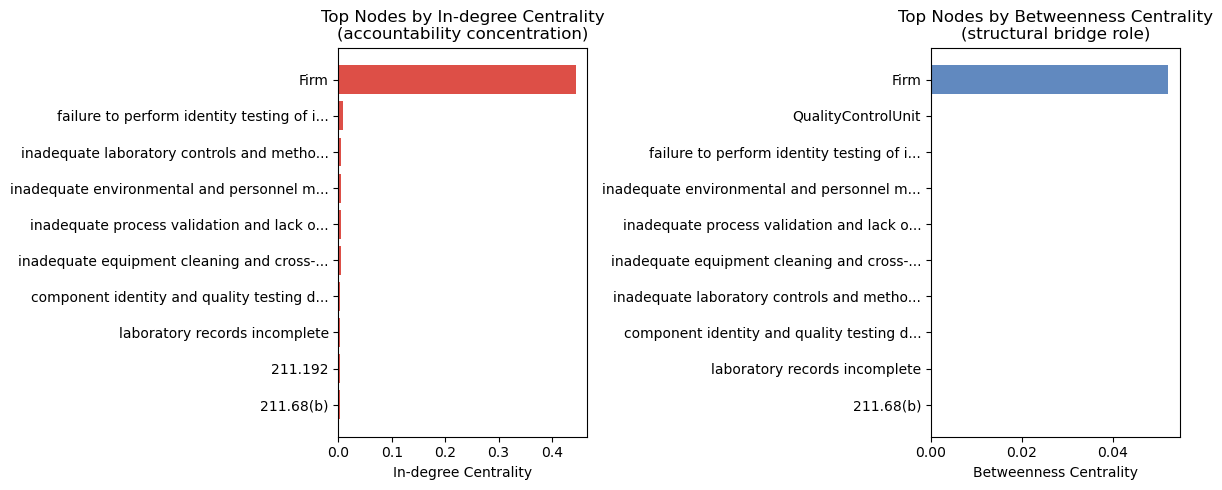

Saved!


In [11]:
# -------------------------------------------------------------
# Step 7: Visualize centrality — Figure 2
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Top 10 by in-degree (excluding violation nodes)
top_nodes = centrality_df[
    centrality_df['node'].astype(str).str.startswith('WL') == False
].head(10)

axes[0].barh(
    [n[:40] + '...' if len(n) > 40 else n for n in top_nodes['node'].astype(str)],
    top_nodes['in_degree'],
    color='#d73027', alpha=0.85
)
axes[0].set_xlabel('In-degree Centrality')
axes[0].set_title('Top Nodes by In-degree Centrality\n(accountability concentration)')
axes[0].invert_yaxis()

# Betweenness centrality
top_between = centrality_df[
    centrality_df['node'].astype(str).str.startswith('WL') == False
].sort_values('betweenness', ascending=False).head(10)

axes[1].barh(
    [n[:40] + '...' if len(n) > 40 else n for n in top_between['node'].astype(str)],
    top_between['betweenness'],
    color='#4575b4', alpha=0.85
)
axes[1].set_xlabel('Betweenness Centrality')
axes[1].set_title('Top Nodes by Betweenness Centrality\n(structural bridge role)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('figures/graph_centrality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [12]:
# -------------------------------------------------------------
# Split figures for paper
# -------------------------------------------------------------

# Figure 1: Accountability Graph
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(SG, seed=42, k=2)
color_map = ['#d73027' if n in subject_nodes else '#4575b4' for n in SG.nodes()]
sizes = [300 + SG.in_degree(n) * 200 for n in SG.nodes()]
nx.draw_networkx(SG, pos, node_color=color_map, node_size=sizes,
    font_size=7, arrows=True, arrowsize=10,
    edge_color='gray', alpha=0.8, ax=ax)
red_patch = mpatches.Patch(color='#d73027', label='Responsibility Subject')
blue_patch = mpatches.Patch(color='#4575b4', label='CFR Regulation')
ax.legend(handles=[red_patch, blue_patch])
ax.axis('off')
plt.tight_layout()
plt.savefig('figures/graph1_accountability.png', dpi=150, bbox_inches='tight')
plt.close()

# Figure 2: In-degree Centrality
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([n[:40] + '...' if len(n) > 40 else n for n in top_nodes['node'].astype(str)],
    top_nodes['in_degree'], color='#d73027', alpha=0.85)
ax.set_xlabel('In-degree Centrality')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/graph2_indegree.png', dpi=150, bbox_inches='tight')
plt.close()

# Figure 3: Betweenness Centrality
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([n[:40] + '...' if len(n) > 40 else n for n in top_between['node'].astype(str)],
    top_between['betweenness'], color='#4575b4', alpha=0.85)
ax.set_xlabel('Betweenness Centrality')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/graph3_betweenness.png', dpi=150, bbox_inches='tight')
plt.close()

print("Figure 1, 2, 3 saved!")

Figure 1, 2, 3 saved!


In [13]:
# -------------------------------------------------------------
# Step 8: Case-level accountability concentration score
# For each case: how concentrated is the accountability graph?
# -------------------------------------------------------------

from scipy.stats import entropy

case_scores = []

for case_id in fda_df['CaseID'].unique():
    case_data = fda_df[fda_df['CaseID'] == case_id]
    
    # How many unique responsibility subjects?
    subjects = case_data['ResponsibilitySubject'].value_counts()
    n_violations = len(case_data)
    n_unique_subjects = len(subjects)
    
    # How many unique CFR sections?
    n_unique_cfr = case_data['CFR'].nunique()
    
    # Subject entropy (diversity of responsibility subjects)
    probs = subjects.values / subjects.values.sum()
    subject_entropy = entropy(probs, base=2)
    
    # Concentration score: low entropy + single subject = high concentration
    concentration = 1 - (subject_entropy / (np.log2(n_violations + 1) + 1e-9))
    
    case_scores.append({
        'case_id': case_id,
        'n_violations': n_violations,
        'n_unique_subjects': n_unique_subjects,
        'n_unique_cfr': n_unique_cfr,
        'subject_entropy': subject_entropy,
        'concentration_score': concentration
    })

scores_df = pd.DataFrame(case_scores).sort_values('concentration_score', ascending=False)

print(f"Total cases: {len(scores_df)}")
print(f"\nTop 10 high concentration cases:")
print(scores_df.head(10)[['case_id', 'n_violations', 'n_unique_subjects', 
                            'subject_entropy', 'concentration_score']].to_string(index=False))

Total cases: 50

Top 10 high concentration cases:
  case_id  n_violations  n_unique_subjects  subject_entropy  concentration_score
WL2016-01             2                  1              0.0                  1.0
WL2016-02             2                  1              0.0                  1.0
WL2016-04             2                  1              0.0                  1.0
WL2016-05             3                  1              0.0                  1.0
WL2017-01             4                  1              0.0                  1.0
WL2017-02             2                  1              0.0                  1.0
WL2017-04             2                  1              0.0                  1.0
WL2017-03             3                  1              0.0                  1.0
WL2017-05             4                  1              0.0                  1.0
WL2018-01             3                  1              0.0                  1.0


In [14]:
# -------------------------------------------------------------
# Step 8 (revised): CFR-based concentration score
# More diverse CFR violations = less concentrated = more open
# -------------------------------------------------------------

case_scores = []

for case_id in fda_df['CaseID'].unique():
    case_data = fda_df[fda_df['CaseID'] == case_id]
    
    n_violations = len(case_data)
    n_unique_cfr = case_data['CFR'].nunique()
    
    # CFR entropy — how diverse are the violations?
    cfr_counts = case_data['CFR'].value_counts()
    probs = cfr_counts.values / cfr_counts.values.sum()
    cfr_entropy = entropy(probs, base=2)
    
    # Concentration = low CFR diversity = violations cluster around few regulations
    max_entropy = np.log2(n_violations + 1e-9)
    concentration = 1 - (cfr_entropy / max_entropy) if max_entropy > 0 else 1.0
    
    case_scores.append({
        'case_id': case_id,
        'n_violations': n_violations,
        'n_unique_cfr': n_unique_cfr,
        'cfr_entropy': round(cfr_entropy, 3),
        'concentration_score': round(concentration, 3)
    })

scores_df = pd.DataFrame(case_scores).sort_values('concentration_score', ascending=False)

print("High concentration cases (violations cluster on few CFR sections):")
print(scores_df.head(10).to_string(index=False))
print(f"\nLow concentration cases (violations spread across CFR sections):")
print(scores_df.tail(5).to_string(index=False))

High concentration cases (violations cluster on few CFR sections):
  case_id  n_violations  n_unique_cfr  cfr_entropy  concentration_score
WL2018-05             1             1        0.000                  1.0
WL2016-01             2             2        1.000                  0.0
WL2016-02             2             2        1.000                  0.0
WL2016-03             6             6        2.585                  0.0
WL2016-05             3             3        1.585                  0.0
WL2016-04             2             2        1.000                  0.0
WL2017-02             2             2        1.000                  0.0
WL2017-03             3             3        1.585                  0.0
WL2017-04             2             2        1.000                  0.0
WL2017-01             4             4        2.000                  0.0

Low concentration cases (violations spread across CFR sections):
  case_id  n_violations  n_unique_cfr  cfr_entropy  concentration_score
WL2

In [15]:
# -------------------------------------------------------------
# Step 9: Composite accountability structure score
# Combines violation count + CFR diversity + text diversity
# -------------------------------------------------------------

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler

# Text diversity per case (TF-IDF based)
case_texts = fda_df.groupby('CaseID')['ViolationText'].apply(
    lambda x: ' '.join(x)
).reset_index()
case_texts.columns = ['case_id', 'combined_text']

# TF-IDF diversity score per case
vectorizer = TfidfVectorizer(max_features=50)
tfidf_matrix = vectorizer.fit_transform(case_texts['combined_text'])

# Text diversity = average TF-IDF score (how unique is this case's vocabulary?)
text_diversity = tfidf_matrix.toarray().mean(axis=1)

# Build composite score dataframe
composite_df = pd.DataFrame({
    'case_id': case_texts['case_id'],
    'text_diversity': text_diversity
})

# Merge with scores
scores_df2 = scores_df.merge(composite_df, on='case_id')

# Normalize all features to 0-1
scaler = MinMaxScaler()
scores_df2['violation_count_norm'] = scaler.fit_transform(
    scores_df2[['n_violations']])
scores_df2['cfr_count_norm'] = scaler.fit_transform(
    scores_df2[['n_unique_cfr']])
scores_df2['text_diversity_norm'] = scaler.fit_transform(
    scores_df2[['text_diversity']])

# Composite openness score (higher = more open/diverse accountability structure)
scores_df2['openness_score'] = (
    scores_df2['violation_count_norm'] * 0.3 +
    scores_df2['cfr_count_norm'] * 0.4 +
    scores_df2['text_diversity_norm'] * 0.3
).round(3)

scores_df2 = scores_df2.sort_values('openness_score', ascending=False)

print("High openness cases (diverse accountability structure):")
print(scores_df2[['case_id', 'n_violations', 'n_unique_cfr', 
                   'openness_score']].head(10).to_string(index=False))

print(f"\nLow openness cases (concentrated accountability structure):")
print(scores_df2[['case_id', 'n_violations', 'n_unique_cfr',
                   'openness_score']].tail(5).to_string(index=False))

High openness cases (diverse accountability structure):
  case_id  n_violations  n_unique_cfr  openness_score
WL2023-05             5             5           0.845
WL2016-03             6             6           0.816
WL2022-04             5             5           0.774
WL2022-01             5             5           0.772
WL2018-02             5             5           0.748
WL2023-01             4             4           0.720
WL2021-01             4             4           0.692
WL2022-02             4             4           0.678
WL2020-01             4             4           0.675
WL2019-02             5             5           0.674

Low openness cases (concentrated accountability structure):
  case_id  n_violations  n_unique_cfr  openness_score
WL2025-05             2             2           0.209
WL2016-04             2             2           0.174
WL2016-02             2             2           0.160
WL2016-01             2             2           0.140
WL2018-05          

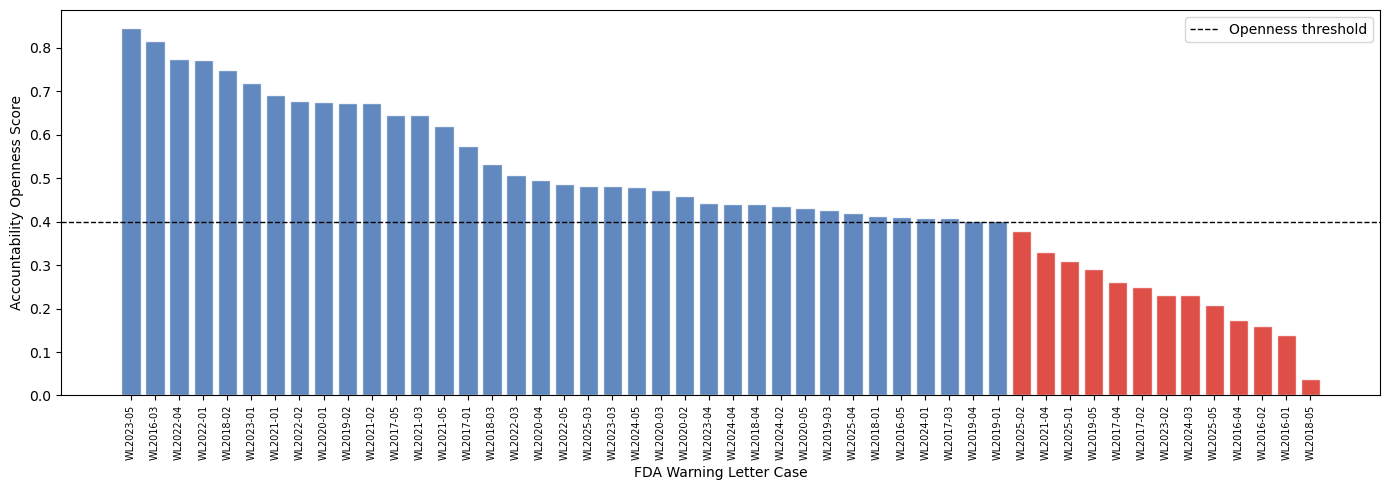

Saved!


In [16]:
# -------------------------------------------------------------
# Step 10: Visualize openness score — Figure 4
# -------------------------------------------------------------

fig, ax = plt.subplots(figsize=(14, 5))

sorted_scores = scores_df2.sort_values('openness_score', ascending=False)
colors = ['#4575b4' if s > 0.4 else '#d73027' 
          for s in sorted_scores['openness_score']]

ax.bar(range(len(sorted_scores)), 
       sorted_scores['openness_score'],
       color=colors, alpha=0.85, edgecolor='white')

ax.axhline(y=0.4, color='black', linestyle='--', 
           linewidth=1, label='Openness threshold')
ax.set_xticks(range(len(sorted_scores)))
ax.set_xticklabels(sorted_scores['case_id'], 
                   rotation=90, fontsize=7)
ax.set_xlabel('FDA Warning Letter Case')
ax.set_ylabel('Accountability Openness Score')
ax.legend()

plt.tight_layout()
plt.savefig('figures/graph4_openness.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

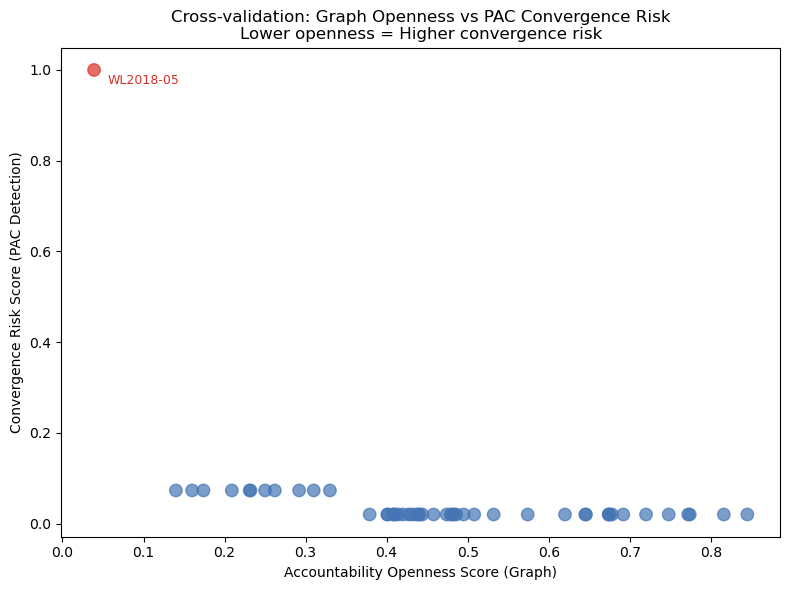

Saved!


In [17]:
# -------------------------------------------------------------
# Step 11: Cross-validation with PAC detection
# Compare openness score vs convergence risk from Project 1
# -------------------------------------------------------------

# PAC detection risk scores from Project 1
pac_risk = {
    'WL2018-05': 1.000, 'WL2016-01': 0.073, 'WL2016-02': 0.073,
    'WL2016-04': 0.073, 'WL2017-04': 0.073, 'WL2017-02': 0.073,
    'WL2023-02': 0.073, 'WL2025-05': 0.073, 'WL2021-04': 0.073,
    'WL2019-05': 0.073, 'WL2024-03': 0.073, 'WL2025-01': 0.073
}

# Merge
scores_df2['pac_risk'] = scores_df2['case_id'].map(pac_risk).fillna(0.02)

# Scatter plot
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#d73027' if cid == 'WL2018-05' else '#4575b4' 
          for cid in scores_df2['case_id']]

ax.scatter(scores_df2['openness_score'], 
           scores_df2['pac_risk'],
           c=colors, alpha=0.7, s=80)

# Label WL2018-05
wl = scores_df2[scores_df2['case_id'] == 'WL2018-05'].iloc[0]
ax.annotate('WL2018-05', 
            (wl['openness_score'], wl['pac_risk']),
            textcoords='offset points', xytext=(10, -10),
            fontsize=9, color='#d73027')

ax.set_xlabel('Accountability Openness Score (Graph)')
ax.set_ylabel('Convergence Risk Score (PAC Detection)')
ax.set_title('Cross-validation: Graph Openness vs PAC Convergence Risk\n'
             'Lower openness = Higher convergence risk')

plt.tight_layout()
plt.savefig('figures/graph5_crossvalidation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [18]:
# -------------------------------------------------------------
# Step 12: Statistical validation
# Pearson + Spearman correlation between openness and PAC risk
# -------------------------------------------------------------

from scipy.stats import pearsonr, spearmanr

x = scores_df2['openness_score']
y = scores_df2['pac_risk']

pearson_r, pearson_p = pearsonr(x, y)
spearman_r, spearman_p = spearmanr(x, y)

print("Statistical Validation: Openness Score vs PAC Convergence Risk")
print("=" * 60)
print(f"Pearson r  = {pearson_r:.3f}  (p = {pearson_p:.4f})")
print(f"Spearman ρ = {spearman_r:.3f}  (p = {spearman_p:.4f})")

if pearson_p < 0.05:
    print(f"\n✅ Significant negative correlation (p < 0.05)")
    print(f"   Lower openness → Higher convergence risk")
else:
    print(f"\n⚠️ Correlation not statistically significant (p = {pearson_p:.4f})")
    print(f"   WL2018-05 may be driving the trend as an outlier")

Statistical Validation: Openness Score vs PAC Convergence Risk
Pearson r  = -0.431  (p = 0.0018)
Spearman ρ = -0.742  (p = 0.0000)

✅ Significant negative correlation (p < 0.05)
   Lower openness → Higher convergence risk


In [19]:
# -------------------------------------------------------------
# Step 13: Extended graph metrics
# PageRank + clustering coefficient per node
# -------------------------------------------------------------

# PageRank — who is most "influential" in the accountability network?
pagerank = nx.pagerank(G2, alpha=0.85)
pagerank_df = pd.DataFrame({
    'node': list(pagerank.keys()),
    'pagerank': list(pagerank.values())
}).sort_values('pagerank', ascending=False)

# Clustering coefficient (undirected version)
G2_undirected = G2.to_undirected()
clustering = nx.clustering(G2_undirected)
clustering_df = pd.DataFrame({
    'node': list(clustering.keys()),
    'clustering': list(clustering.values())
}).sort_values('clustering', ascending=False)

print("Top 10 nodes by PageRank:")
print(pagerank_df[~pagerank_df['node'].astype(str).str.startswith('WL')].head(10).to_string(index=False))

print(f"\nTop 10 nodes by Clustering Coefficient:")
print(clustering_df[
    ~clustering_df['node'].astype(str).str.startswith('WL')
].head(10).to_string(index=False))

Top 10 nodes by PageRank:
          node  pagerank
          Firm  0.123686
 211.194(a)(4)  0.004305
    211.110(a)  0.004305
    211.194(a)  0.004305
     211.22(d)  0.004305
     211.68(b)  0.004305
     211.68(a)  0.004305
    211.160(b)  0.004305
 211.22(a),(d)  0.004305
211.165(a),(b)  0.004305

Top 10 nodes by Clustering Coefficient:
                                                                                              node  clustering
                            inadequate validation and control of aseptic decontamination processes           0
                                                                                              Firm           0
                                                                                211.42(c)(10)(iv))           0
                                                                   environmental monitoring system           0
                                                                                        211.113(b)     

In [20]:
# -------------------------------------------------------------
# Step 14: Case clustering based on graph structure
# Group cases by their accountability graph features
# -------------------------------------------------------------

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Build feature matrix per case
case_features = scores_df2[[
    'n_violations',
    'n_unique_cfr',
    'cfr_entropy',
    'openness_score',
    'pac_risk'
]].copy()

case_ids = scores_df2['case_id'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(case_features)

# K-means clustering (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
scores_df2['cluster'] = clusters

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
scores_df2['pca1'] = X_pca[:, 0]
scores_df2['pca2'] = X_pca[:, 1]

print(f"Cluster distribution:")
print(scores_df2['cluster'].value_counts().sort_index())
print(f"\nCluster profiles:")
print(scores_df2.groupby('cluster')[
    ['n_violations', 'n_unique_cfr', 'openness_score', 'pac_risk']
].mean().round(3))

Cluster distribution:
cluster
0    16
1    33
2     1
Name: count, dtype: int64

Cluster profiles:
         n_violations  n_unique_cfr  openness_score  pac_risk
cluster                                                      
0               4.438         4.438           0.693     0.020
1               2.667         2.667           0.373     0.038
2               1.000         1.000           0.039     1.000


C:\Users\user\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


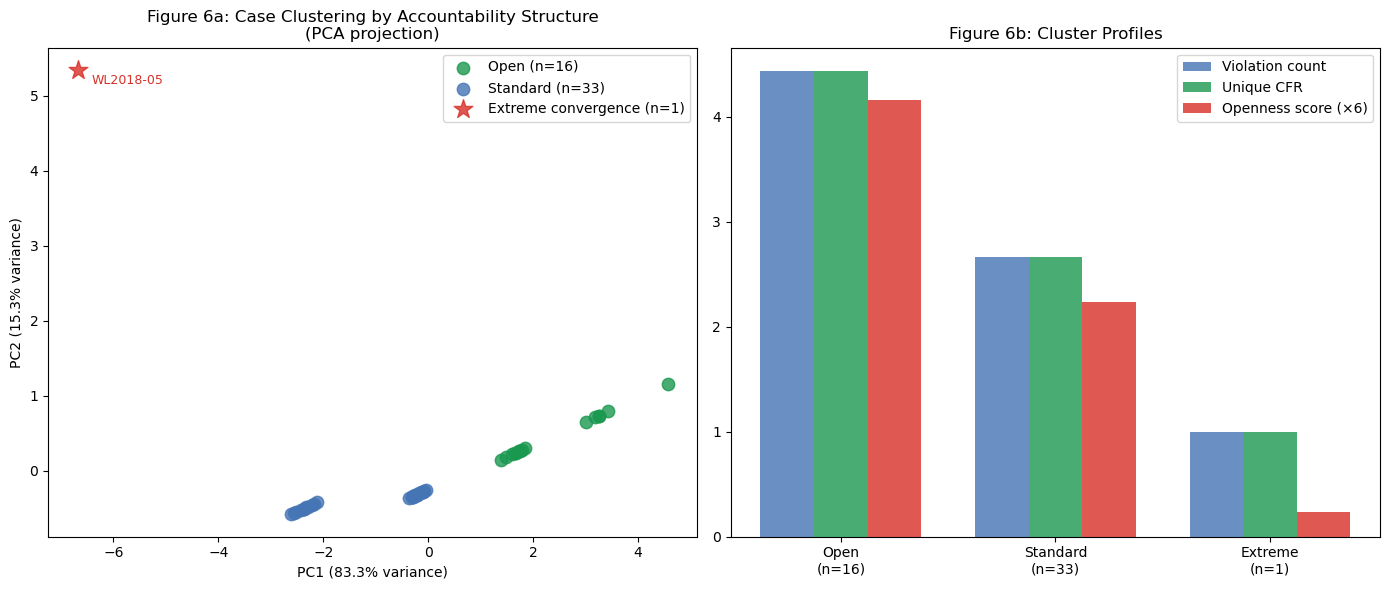

Saved!


In [21]:
# -------------------------------------------------------------
# Step 15: Visualize clusters — Figure 6
# -------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Figure 6a: PCA scatter
cluster_colors = {0: '#1a9850', 1: '#4575b4', 2: '#d73027'}
cluster_labels = {
    0: 'Open (n=16)', 
    1: 'Standard (n=33)', 
    2: 'Extreme convergence (n=1)'
}

for c in [0, 1, 2]:
    mask = scores_df2['cluster'] == c
    axes[0].scatter(
        scores_df2[mask]['pca1'],
        scores_df2[mask]['pca2'],
        c=cluster_colors[c],
        label=cluster_labels[c],
        s=80 if c != 2 else 200,
        alpha=0.8,
        marker='o' if c != 2 else '*'
    )

# Label WL2018-05
wl = scores_df2[scores_df2['case_id'] == 'WL2018-05'].iloc[0]
axes[0].annotate('WL2018-05',
    (wl['pca1'], wl['pca2']),
    textcoords='offset points', xytext=(10, -10),
    fontsize=9, color='#d73027')

axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].set_title('Figure 6a: Case Clustering by Accountability Structure\n(PCA projection)')
axes[0].legend()

# Figure 6b: Cluster profile bar chart
cluster_means = scores_df2.groupby('cluster')[
    ['n_violations', 'n_unique_cfr', 'openness_score']
].mean()

x = np.arange(3)
width = 0.25
axes[1].bar(x - width, cluster_means['n_violations'], 
            width, label='Violation count', color='#4575b4', alpha=0.8)
axes[1].bar(x, cluster_means['n_unique_cfr'], 
            width, label='Unique CFR', color='#1a9850', alpha=0.8)
axes[1].bar(x + width, cluster_means['openness_score'] * 6, 
            width, label='Openness score (×6)', color='#d73027', alpha=0.8)

axes[1].set_xticks(x)
axes[1].set_xticklabels(['Open\n(n=16)', 'Standard\n(n=33)', 'Extreme\n(n=1)'])
axes[1].set_title('Figure 6b: Cluster Profiles')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/graph6_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [22]:
# -------------------------------------------------------------
# Re-save all figures WITHOUT titles
# -------------------------------------------------------------

import os
os.makedirs('figures', exist_ok=True)

# graph1: Accountability Graph
fig, ax = plt.subplots(figsize=(12, 9))
pos = nx.spring_layout(SG, seed=42, k=2)
color_map = ['#d73027' if n in subject_nodes else '#4575b4' for n in SG.nodes()]
sizes = [300 + SG.in_degree(n) * 200 for n in SG.nodes()]
nx.draw_networkx(SG, pos, node_color=color_map, node_size=sizes,
    font_size=7, arrows=True, arrowsize=10,
    edge_color='gray', alpha=0.8, ax=ax)
red_patch = mpatches.Patch(color='#d73027', label='Responsibility Subject')
blue_patch = mpatches.Patch(color='#4575b4', label='CFR Regulation')
ax.legend(handles=[red_patch, blue_patch])
ax.axis('off')
plt.tight_layout()
plt.savefig('figures/graph1_accountability.png', dpi=150, bbox_inches='tight')
plt.close()

# graph2: In-degree Centrality
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([n[:40] + '...' if len(n) > 40 else n for n in top_nodes['node'].astype(str)],
    top_nodes['in_degree'], color='#d73027', alpha=0.85)
ax.set_xlabel('In-degree Centrality')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/graph2_indegree.png', dpi=150, bbox_inches='tight')
plt.close()

# graph3: Betweenness Centrality
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([n[:40] + '...' if len(n) > 40 else n for n in top_between['node'].astype(str)],
    top_between['betweenness'], color='#4575b4', alpha=0.85)
ax.set_xlabel('Betweenness Centrality')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('figures/graph3_betweenness.png', dpi=150, bbox_inches='tight')
plt.close()

# graph4: Openness Score
fig, ax = plt.subplots(figsize=(14, 5))
sorted_scores = scores_df2.sort_values('openness_score', ascending=False)
colors = ['#4575b4' if s > 0.4 else '#d73027' for s in sorted_scores['openness_score']]
ax.bar(range(len(sorted_scores)), sorted_scores['openness_score'],
    color=colors, alpha=0.85, edgecolor='white')
ax.axhline(y=0.4, color='black', linestyle='--', linewidth=1, label='Openness threshold')
ax.set_xticks(range(len(sorted_scores)))
ax.set_xticklabels(sorted_scores['case_id'], rotation=90, fontsize=7)
ax.set_xlabel('FDA Warning Letter Case')
ax.set_ylabel('Accountability Openness Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/graph4_openness.png', dpi=150, bbox_inches='tight')
plt.close()

# graph5: Cross-validation
fig, ax = plt.subplots(figsize=(8, 6))
colors_scatter = ['#d73027' if cid == 'WL2018-05' else '#4575b4'
          for cid in scores_df2['case_id']]
ax.scatter(scores_df2['openness_score'], scores_df2['pac_risk'],
    c=colors_scatter, alpha=0.7, s=80)
wl = scores_df2[scores_df2['case_id'] == 'WL2018-05'].iloc[0]
ax.annotate('WL2018-05', (wl['openness_score'], wl['pac_risk']),
    textcoords='offset points', xytext=(10, -10), fontsize=9, color='#d73027')
ax.set_xlabel('Accountability Openness Score (Graph)')
ax.set_ylabel('Convergence Risk Score (PAC Detection)')
plt.tight_layout()
plt.savefig('figures/graph5_crossvalidation.png', dpi=150, bbox_inches='tight')
plt.close()

# graph6: Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for c in [0, 1, 2]:
    mask = scores_df2['cluster'] == c
    axes[0].scatter(scores_df2[mask]['pca1'], scores_df2[mask]['pca2'],
        c=cluster_colors[c], label=cluster_labels[c],
        s=80 if c != 2 else 200, alpha=0.8,
        marker='o' if c != 2 else '*')
wl = scores_df2[scores_df2['case_id'] == 'WL2018-05'].iloc[0]
axes[0].annotate('WL2018-05', (wl['pca1'], wl['pca2']),
    textcoords='offset points', xytext=(10, -10), fontsize=9, color='#d73027')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
axes[0].legend()
cluster_means = scores_df2.groupby('cluster')[['n_violations', 'n_unique_cfr', 'openness_score']].mean()
x = np.arange(3)
width = 0.25
axes[1].bar(x - width, cluster_means['n_violations'], width, label='Violation count', color='#4575b4', alpha=0.8)
axes[1].bar(x, cluster_means['n_unique_cfr'], width, label='Unique CFR', color='#1a9850', alpha=0.8)
axes[1].bar(x + width, cluster_means['openness_score'] * 6, width, label='Openness score (×6)', color='#d73027', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Open\n(n=16)', 'Standard\n(n=33)', 'Extreme\n(n=1)'])
axes[1].legend()
plt.tight_layout()
plt.savefig('figures/graph6_clusters.png', dpi=150, bbox_inches='tight')
plt.close()

print("All 6 figures saved without titles!")

All 6 figures saved without titles!
